# Distance estimation from multi-tone phase

A transmitter emits $N$ orthogonal tones at baseband frequencies

$$f_k \;=\; k\,\Delta f, \qquad k = 0, 1, \dots, N-1, \qquad \Delta f = 1\,\mathrm{MHz}.$$

Each tone propagates over a (one-way) distance $d$, accumulating a phase

$$\phi_k \;=\; -2\pi f_k\, \tau, \qquad \tau = d/c.$$

So **phase is linear in frequency** with slope $-2\pi\tau$. The receiver demodulates each tone, measures its phase $\phi_k$, fits a line, and recovers

$$\boxed{\;\hat{d} \;=\; -\,\frac{c}{2\pi}\,\frac{d\phi}{df}.\;}$$

#### Assumptions

- All $N$ tones are transmitted simultaneously as one OFDM-like symbol of duration $T = 1/\Delta f$ (so the tones are mutually orthogonal over the symbol).
- Sample rate $f_s = \mathrm{OSR}\cdot N\,\Delta f$ with $\mathrm{OSR}=8$, giving $M = \mathrm{OSR}\cdot N$ samples per symbol.
- Receiver demodulation = DFT bin extraction (correlate with $e^{-j2\pi f_k t}$ over $[0,T]$).

#### Unambiguous range

Phase wraps every $2\pi$, so consecutive tones must differ by less than $\pi$ for unwrapping to succeed. That gives

$$d_\text{max} \;=\; \frac{c}{2\Delta f} \;=\; \frac{3\!\times\!10^8}{2\cdot 10^6} \;=\; 150\,\mathrm{m}.$$

#### Frequency offset

If the Rx local oscillator is offset by $\delta f$ from the Tx LO, adjacent tones leak into each other (**inter-carrier interference, ICI**), which biases the per-tone phase and therefore the recovered distance.

We simulate this below and quantify the bias as a function of $\delta f$.


---

### Distance estimation via MUSIC

The per-tone phasors form a length-$N$ complex sinusoid in *tone index* $k$:

$$y_k \;=\; e^{-j 2\pi (k\Delta f)\,\tau} \;+\; w_k \;=\; e^{-j 2\pi (\Delta f\,\tau)\,k} \;+\; w_k.$$

So estimating $\tau$ from $\{y_k\}$ is the same problem as estimating the *frequency* of a complex sinusoid — and **MUSIC** (MUltiple SIgnal Classification) is the classic subspace method for that.

**Algorithm.** Use *forward spatial smoothing* on the length-$N$ tone vector to form $K = N-L+1$ length-$L$ snapshots, average them into a sample covariance

$$\hat R \;=\; \frac{1}{K}\sum_{l=0}^{K-1} \tilde y_l\,\tilde y_l^{H}, \qquad \tilde y_l \;=\; (y_l, y_{l+1},\dots,y_{l+L-1})^{\!\top},$$

and compute its eigendecomposition. With $P$ paths, the $L-P$ smallest eigenvectors span the **noise subspace** $V_n$. The MUSIC pseudo-spectrum

$$P_\text{MUSIC}(\tau) \;=\; \frac{1}{\|V_n^{H}\,a(\tau)\|^{2}}, \qquad a(\tau) \;=\; \bigl[e^{-j 2\pi (l\Delta f)\,\tau}\bigr]_{l=0}^{L-1}$$

peaks where $a(\tau)$ is *orthogonal* to the noise subspace — at the true delay $\tau$. We sweep $\tau$ (or equivalently $d = c\tau$) over a fine grid and pick the largest peaks.

For a **single path** ($P{=}1$), MUSIC isn't asymptotically more accurate than the slope fit — both are equivalent to the MLE. The real value of MUSIC shows up under multipath.

#### Multipath

With $P > 1$ paths the receive vector becomes

$$y_k \;=\; \sum_{p=1}^{P} A_p\, e^{-j 2\pi k \Delta f\, \tau_p} \;+\; w_k,$$

i.e. a sum of $P$ complex sinusoids in tone index $k$, one per path. Three things change in the algorithm:

- **The signal subspace gains rank.** The eigendecomposition of $\hat R$ now has $P$ "large" eigenvalues (signal) and $L-P$ small ones (noise). $V_n$ shrinks to dimension $L-P$, and each true delay $\tau_p$ produces its own peak in $P_\text{MUSIC}$ — slope-fit, by contrast, can only return one delay and averages the paths into a biased single estimate.
- **Smoothing is what makes coherent paths separable.** All paths arrive within one OFDM symbol, so from a single observation the path-amplitude "covariance" is rank-1 ($A A^{H}$, not $\mathrm{diag}(|A_p|^2)$) and MUSIC fails. Forward spatial smoothing — averaging $K = N-L+1$ shifted length-$L$ snapshots — decorrelates them because each shift multiplies the $p$-th path by a different phase $e^{-j 2\pi l \Delta f \tau_p}$, restoring the signal-subspace rank up to $\min(K, P)$. This is also why the constraint is $P+1 \le L < N$: the upper bound keeps $K \ge 2$, the lower keeps a non-empty noise subspace.
- **$P$ has to be set correctly.** Too low and path energy stays in $V_n$, washing out peaks; too high and noise eigenvectors get promoted to the signal side, creating spurious ones. `music_distance` exposes `P` as a parameter; for the channel model in this notebook, set it to `n_paths`.

Resolution is bounded by the array aperture $N\Delta f$: paths separated by $\ll c/(N\Delta f)$ merge into a single peak regardless of grid density. The default `n_grid=4000` over $[0, c/(2\Delta f))$ sets the *display* resolution (~37 mm), which is much finer than the underlying physical resolution.

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def auto_signal_dim(eigvals, P_max=5, L_max=None):
    """Pick the signal-subspace dimension at the largest log-eigengap, capped.

    Searches the largest log-spaced gap among the first ``P_max + 1``
    eigenvalues — i.e. ``argmax`` over gaps[0..P_max-1] where
    gap_p = log(λ_p / λ_{p+1}). This caps the resulting P at P_max and
    avoids spurious gaps deep in the noise tail at low SNR (where logs of
    tiny eigvals create large random ratios).

    Set ``P_max`` to the maximum number of signal paths you'd believe in
    (channel-dependent). For first-arrival ranging a single-digit cap is
    typically enough — the LOS plus a handful of dominant reflections.

    Parameters
    ----------
    eigvals : (L,) array of eigenvalues (any order; non-negative expected).
    P_max   : upper cap on P; the gap search is restricted to the top P_max+1
              eigvals. Clamped to [1, L-1].
    L_max   : optional MUSIC validity cap (e.g. L - 1 to satisfy P + 1 <= L).

    Returns
    -------
    P : int >= 1.
    """
    eigvals_desc = np.sort(np.asarray(eigvals))[::-1]
    log_ev = np.log(np.maximum(eigvals_desc, np.finfo(float).tiny))
    L = log_ev.size
    P_max_eff = max(1, min(int(P_max), L - 1))
    gaps = log_ev[:P_max_eff] - log_ev[1:P_max_eff + 1]   # gap_p, p = 0..P_max_eff-1
    P = int(np.argmax(gaps)) + 1
    if L_max is not None:
        P = min(P, L_max)
    return max(1, P)


def music_distance(phasors, delta_f, P='auto', P_max=5, L=None, n_grid=1500, d_max=None,
                   alg='1-way', threshold=1.0):
    """Distance estimation via MUSIC on multi-tone phasors.

    Models y_k = sum_p A_p * exp(-j 2π k Δf τ_p) + noise as a sum of P complex
    sinusoids in tone index k with frequencies Δf·τ_p. Forward spatial smoothing
    turns the N-tone vector into N-L+1 length-L snapshots, enabling MUSIC for
    delay/distance estimation.

    Parameters
    ----------
    phasors   : (N,) complex per-tone phasors (e.g. ``simulate()``'s third return).
    delta_f   : tone spacing (Hz).
    P         : number of signal paths. Either a positive int or 'auto' (default)
                to pick P at the largest log-eigengap via ``auto_signal_dim``;
                the auto choice is clamped to L-1 so the MUSIC constraint
                P + 1 <= L holds.
    P_max     : upper cap on auto-mode P (default 5). Ignored if P is an int.
    L         : subarray length (default N//2). Bigger L sharpens the steering
                vector at the cost of fewer snapshots.
    n_grid    : number of distance candidates in the search grid.
    d_max     : max distance to search (defaults to c/(2·delta_f), matching the
                slope-fit unambiguous range).
    threshold : minimum P_MUSIC value for a local max to qualify as a peak.
                The off-peak baseline sits near 1.0; the default 1.0 keeps any
                peak that rises above it.

    Returns
    -------
    d_hat     : (≤P,) distances of the up to P earliest local maxima of the
                pseudo-spectrum with P_MUSIC > threshold (first-arrival semantics
                for ranging). Local maxima at-or-below the threshold are dropped
                as noise-floor ripple.
    distances : (n_grid,) the search grid (m).
    P_music   : (n_grid,) the MUSIC pseudo-spectrum values.
    eigvals   : (L,) sample-covariance eigenvalues sorted descending; the top P
                are the signal eigenvalues, the remaining L-P the noise floor.
    """
    y = np.asarray(phasors)
    N = len(y)
    if L is None:
        L = N // 2
    if d_max is None:
        d_max = c / (2 * delta_f)

    # Forward spatial smoothing: K = N - L + 1 length-L snapshots.
    K = N - L + 1
    Y = np.empty((L, K), dtype=complex)
    for l in range(K):
        Y[:, l] = y[l : l + L]
    R = Y @ Y.conj().T / K

    # Eigendecomp; np.linalg.eigh returns ascending eigenvalues.
    eigvals, V = np.linalg.eigh(R)

    if P == 'auto':
        P = auto_signal_dim(eigvals, P_max=P_max, L_max=L - 1)

    if not (P + 1 <= L < N):
        raise ValueError(f"need P+1 <= L < N (got P={P}, L={L}, N={N})")

    V_noise = V[:, : L - P]   # the L-P smallest eigenvectors

    # Pseudo-spectrum P(d) = 1 / ||V_noise^H a(d)||^2 on a distance grid.
    distances = np.linspace(0, d_max, n_grid)
    sub_freqs = np.arange(L) * delta_f                                # (L,)
    A = np.exp(-2j * np.pi * np.outer(sub_freqs, distances / c))      # (L, n_grid)
    proj = V_noise.conj().T @ A                                       # (L-P, n_grid)
    P_music = 1.0 / np.sum(np.abs(proj) ** 2, axis=0)

    # First-arrival semantics: take the P earliest local maxima by distance,
    # qualifying peaks at P_MUSIC > threshold (the off-peak baseline value of
    # 1 / ||V_n^H a||^2 sits near 1, so signal peaks rise above it).
    # Under multipath the strongest tap need not be the LOS path, so picking
    # by amplitude would bias the range estimate; arrival order is the right
    # signal for ranging.
    is_peak = np.r_[False, (P_music[1:-1] > P_music[:-2]) & (P_music[1:-1] > P_music[2:]), False]
    peak_idx = np.flatnonzero(is_peak & (P_music > threshold))[:P]
    if peak_idx.size == 0:
        # No peak crossed the threshold (e.g. very low SNR): fall back to argmax.
        peak_idx = np.array([np.argmax(P_music)])
    d_hat = distances[peak_idx]

    if alg=='2-way':
        distances /= 2.0
        d_hat /= 2.0

    return d_hat, distances, P_music, eigvals[::-1]


In [3]:
c = 3e8                              # speed of light (m/s)
N = 80                               # number of orthogonal tones
delta_f = 1e6                        # tone spacing (Hz)
OSR = 8                              # oversampling ratio
fs = OSR * N * delta_f               # sample rate (Hz)
T_sym = 1 / delta_f                  # OFDM symbol duration (s)
M = OSR * N                          # samples per symbol
t = np.arange(M) / fs                # sample times within one symbol
freqs = np.arange(N) * delta_f       # tone frequencies (baseband)
d_max = c / (2 * delta_f)            # max unambiguous distance (m)

print(f"N = {N} tones,  delta_f = {delta_f/1e6:.1f} MHz,  OSR = {OSR}")
print(f"fs = {fs/1e6:.0f} MHz,  M = {M} samples,  T = {T_sym*1e6:.2f} us")
print(f"unambiguous range: 0 < d < {d_max:.1f} m")


def channel(d_true, delay_spread=0.0, n_paths=8, los=True, n_tones=None, rng=None):
    """Multipath channel frequency response.

    LOS mode (default): a unit-amplitude line-of-sight tap at delay τ₀ = d_true/c,
    plus n_paths−1 reflected taps with excess delays drawn from an exponential
    distribution of mean = delay_spread. Each reflected tap has magnitude
    exp(−Δτ/(2·delay_spread)) (so power decays exponentially with excess delay)
    and a uniformly random phase.

    NLOS mode (los=False): the deterministic LOS tap is removed — all n_paths
    taps are reflections with random excess delays and phases. The first-
    arriving tap is forced to be weaker than the strongest later reflection
    (modeling a faint diffracted/grazing path masked by a stronger specular
    reflection). This biases amplitude-based estimators toward the later path
    while first-arrival pickers still recover the leading edge.

    With delay_spread = 0 (or n_paths ≤ 1) the channel collapses to the single-
    path LOS case H(f) = exp(−j 2π f τ₀) regardless of the los flag (NLOS is
    ill-defined without delay spread).

    Parameters
    ----------
    d_true       : Tx-Rx propagation distance for the LOS tap (m).
    delay_spread : RMS delay spread of the multipath taps (s). 0 = single-path.
    n_paths      : total number of taps (default 8).
    los          : include the deterministic LOS tap (default True).
    n_tones      : optional override of the global N (sets M = OSR · N_).
    rng          : numpy Generator (defaults to a fresh one per call).

    Returns
    -------
    H : (M,) complex array, the channel frequency response on the FFT grid.
    """
    rng = rng if rng is not None else np.random.default_rng()
    N_ = N if n_tones is None else int(n_tones)
    M_ = OSR * N_
    fs_ = OSR * N_ * delta_f
    fft_bins = np.fft.fftfreq(M_, d=1/fs_)

    tau_los = d_true / c

    # Single-path shortcut: degenerate without spread, so always LOS here.
    if delay_spread <= 0 or n_paths <= 1:
        return np.exp(-2j * np.pi * fft_bins * tau_los).astype(np.complex64)

    if los:
        # LOS tap at excess 0; reflections at excess ~ Exponential(delay_spread).
        excess = np.empty(n_paths)
        excess[0] = 0.0
        excess[1:] = rng.exponential(delay_spread, n_paths - 1)
        amplitudes = np.ones(n_paths, dtype=complex)
        amp_mag = np.exp(-excess[1:] / (2.0 * delay_spread))
        tap_phases = rng.uniform(0, 2 * np.pi, n_paths - 1)
        amplitudes[1:] = amp_mag * np.exp(1j * tap_phases)
    else:
        # NLOS: every tap is a random reflection.
        excess = rng.exponential(delay_spread, n_paths)
        amp_mag = np.exp(-excess / (2.0 * delay_spread))
        tap_phases = rng.uniform(0, 2 * np.pi, n_paths)
        # Force the first-arriving tap to be weaker than the strongest of the
        # remaining reflections, so amplitude-based pickers are misled while a
        # first-arrival picker still wins.
        if n_paths >= 2:
            first = int(np.argmin(excess))
            others_max = amp_mag[np.arange(n_paths) != first].max()
            amp_mag[first] = 0.5 * others_max
        amplitudes = (amp_mag * np.exp(1j * tap_phases)).astype(complex)

    # Sum the per-tap exponentials over the FFT-bin grid.
    delays = tau_los + excess                                          # (n_paths,)
    phasors = np.exp(-2j * np.pi * fft_bins[None, :] * delays[:, None])  # (n_paths, M_)
    H = (amplitudes[:, None] * phasors).sum(axis=0)
    return H.astype(np.complex64)


def transmit(delay=1e-9, n_tones=None):
    """Generate the Tx multi-tone frequency-domain spectrum (no channel delay).

    The N tones occupy FFT bins [0, N) with unit magnitude and a small random
    phase offset drawn uniformly in [0, 2π·delay/T_sym] to model LO phase noise.
    The remaining (M - N) bins (the OSR-1 oversampling band) are zero.

    Parameters
    ----------
    delay   : Tx LO phase-noise scale (s).
    n_tones : optional override of the global N. If given, M is recomputed.

    Returns
    -------
    TX : (M,) complex array, the frequency-domain Tx spectrum.
    """
    N_ = N if n_tones is None else int(n_tones)
    M_ = OSR * N_
    phi = 2 * np.pi * delay / T_sym
    phase_offsets = np.random.uniform(0, phi, N_)
    TX = np.zeros(M_, dtype=np.complex64)
    TX[:N_] = np.exp(-1j * phase_offsets)
    return TX


def simulate(d_true, freq_offset=0.0, snr_db=np.inf, delay=1e-9, delay_spread=0.0, n_paths=8,
             los=True, n_tones=None, method='line_fit', P='auto', P_max=5, alg='1-way',
             music_threshold=1.0, rng=None):
    """Single-symbol simulation: Tx multitone -> channel -> Rx -> distance estimate.

    Parameters
    ----------
    d_true      : true Tx-Rx distance (m)
    freq_offset : Tx-Rx LO frequency mismatch (Hz)
    snr_db      : per-sample SNR in dB (np.inf for no noise)
    los         : pass-through to channel(); False for NLOS (no direct tap).
    n_tones     : optional override of the global N. If provided, fs/M/t/freqs
                  are recomputed for this run only.
    P           : MUSIC signal-subspace dim (int) or 'auto' (default).
    P_max       : upper cap on auto-mode P (default 5). Ignored if P is an int.
    music_threshold : peak-detection threshold for the MUSIC estimator.
    rng         : numpy Generator (defaults to a fresh one per call)

    Returns
    -------
    d_hat   : estimated distance (m)
    phases  : (N,) unwrapped per-tone phases used for the slope fit
    phasors : (N,) complex correlator outputs
    slope, intercept : linear fit of phase vs frequency
    """
    rng = rng if rng is not None else np.random.default_rng()

    # Resolve N and dependent quantities (override module defaults if n_tones given).
    if n_tones is None:
        N_, fs_, M_, t_, freqs_ = N, fs, M, t, freqs
    else:
        N_ = int(n_tones)
        fs_ = OSR * N_ * delta_f
        M_ = OSR * N_
        t_ = np.arange(M_) / fs_
        freqs_ = np.arange(N_) * delta_f

    # Tx multitone (no channel applied yet).
    TX = transmit(delay=delay, n_tones=N_)

    # Multipath channel frequency response, applied as a spectral multiply.
    H = channel(d_true, delay_spread=delay_spread, n_paths=n_paths, los=los, n_tones=N_, rng=rng)
    TX = TX * H

    # Independent complex AWGN per leg (initiator + reflector), added in
    # the frequency domain before any 2-way squaring.
    if np.isfinite(snr_db):
        sig_pow = np.mean(np.abs(TX)**2)
        noise_pow = sig_pow / 10**(snr_db / 10)
        w1 = (rng.standard_normal(M_) + 1j * rng.standard_normal(M_)) * np.sqrt(noise_pow / 2)
        w2 = (rng.standard_normal(M_) + 1j * rng.standard_normal(M_)) * np.sqrt(noise_pow / 2)
    else:
        w1 = w2 = 0.0

    TX_i = TX + w1
    TX_r = TX + w2

    if alg == '2-way':
        TX = TX_i * TX_r
    else:
        TX = TX_i

    # Time-domain signal
    rx = np.fft.ifft(TX)

    # Tx-Rx LO frequency offset rotates the received signal at rate -freq_offset.
    rx = rx * np.exp(-2j * np.pi * freq_offset * t_)

    # FFT demodulation: bin index j corresponds to frequency j*fs/M = j*delta_f,
    # so bin k is exactly tone f_k = k*delta_f.
    phasors = np.fft.fft(rx)[:N_]

    # Unwrap phase across tones (phase decreases linearly with frequency for d > 0).
    phases = np.unwrap(np.angle(phasors))

    # Distance estimation: 'line_fit' (default) or 'music'.
    if method == 'line_fit':
        slope, intercept = np.polyfit(freqs_, phases, 1)
        d_hat = -c * slope / (2 * np.pi)
    elif method == 'music':
        d_hat_arr, *_ = music_distance(phasors, delta_f, P=P, P_max=P_max, alg=alg,
                                       threshold=music_threshold)
        d_hat = float(d_hat_arr[0])
        # Synthesize an equivalent slope/intercept so callers that plot a fit
        # line still get something coherent. In 2-way the measured phase ramp
        # is doubled (TX is squared), so the displayed line uses 2·d_hat.
        round_trip = 2.0 if alg == '2-way' else 1.0
        slope = -2 * np.pi * round_trip * d_hat / c
        intercept = 0.0
    else:
        raise ValueError(f"unknown method: {method!r} (use 'line_fit' or 'music')")

    return d_hat, phases, phasors, slope, intercept, H


N = 80 tones,  delta_f = 1.0 MHz,  OSR = 8
fs = 640 MHz,  M = 640 samples,  T = 1.00 us
unambiguous range: 0 < d < 150.0 m


### Single-shot sanity check

Pick a true distance and verify the estimator recovers it (no offset, no noise). Then visualize the phase-vs-frequency line that the slope fit acts on.


true     : 3.0000 m
estimate : 2.9998 m   (residual: -2.244e-04 m)
true     : 3.0000 m
estimate : 2.9947 m   (residual: -5.258e-03 m)


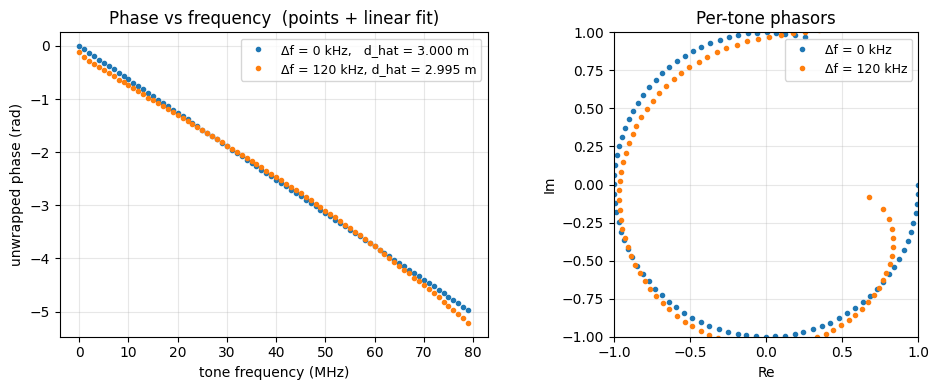


MUSIC d̂ (Δf = 0 kHz)            : 3.0020 m   (residual: +2.001e-03 m)
MUSIC d̂ (Δf = 120 kHz) : 3.0020 m   (residual: +2.001e-03 m)


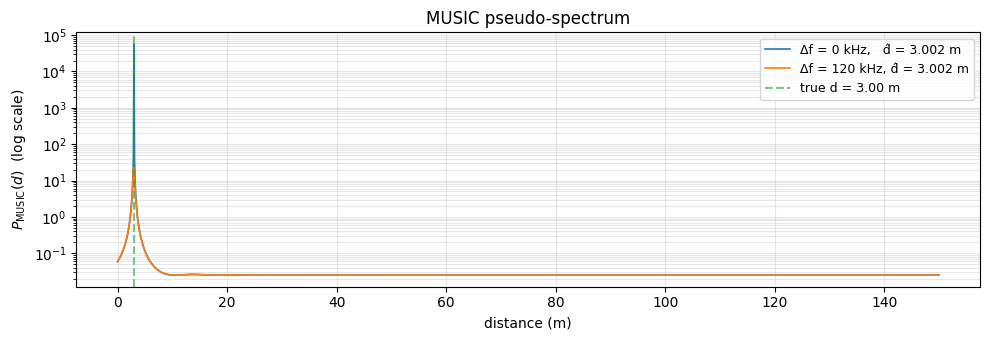

In [4]:
d_true = 3.0   # m
snr_db = np.inf
freq_offset_1 = 120e3   # Hz
alg = '1-way'

# Clean recovery: no offset, no noise.
d_hat_0, phases_0, phasors_0, m_0, b_0, _ = simulate(d_true, snr_db=snr_db, freq_offset=0, alg=alg)
print(f"true     : {d_true:.4f} m")
print(f"estimate : {d_hat_0:.4f} m   (residual: {d_hat_0 - d_true:+.3e} m)")

d_hat_1, phases_1, phasors_1, m_1, b_1, _ = simulate(d_true, snr_db=snr_db, freq_offset=freq_offset_1, alg=alg)
print(f"true     : {d_true:.4f} m")
print(f"estimate : {d_hat_1:.4f} m   (residual: {d_hat_1 - d_true:+.3e} m)")

# Pin colors explicitly so points and fit lines (and right-panel phasors) match
# across both axes -- avoids matplotlib's prop-cycle advancing on each plot call.
c0, c1 = 'C0', 'C1'

plt.figure(figsize=(10, 4))

ax1 = plt.subplot(121)
# Phase points + fit lines (slope, intercept come straight from simulate()).
ax1.plot(freqs/1e6, phases_0, '.', color=c0, label=f'Δf = 0 kHz,   d_hat = {d_hat_0:.3f} m')
ax1.plot(freqs/1e6, phases_1, '.', color=c1, label=f'Δf = {freq_offset_1/1e3:.0f} kHz, d_hat = {d_hat_1:.3f} m')
ax1.set_xlabel('tone frequency (MHz)')
ax1.set_ylabel('unwrapped phase (rad)')
ax1.set_title('Phase vs frequency  (points + linear fit)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

ax2 = plt.subplot(122)
ax2.plot(np.real(phasors_0), np.imag(phasors_0), '.', color=c0, label='Δf = 0 kHz')
ax2.plot(np.real(phasors_1), np.imag(phasors_1), '.', color=c1, label=f'Δf = {freq_offset_1/1e3:.0f} kHz')
ax2.set_xlim(-1, 1)
ax2.set_ylim(-1, 1)
ax2.set_aspect('equal')
ax2.set_xlabel('Re')
ax2.set_ylabel('Im')
ax2.set_title('Per-tone phasors')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


# --- MUSIC on the same two phasor sets ---
d_music_0, dist_grid_0, P_0, _ = music_distance(phasors_0, delta_f, alg=alg)
d_music_1, dist_grid_1, P_1, _ = music_distance(phasors_1, delta_f, alg=alg)
print()
print(f"MUSIC d̂ (Δf = 0 kHz)            : {d_music_0[0]:.4f} m   (residual: {d_music_0[0] - d_true:+.3e} m)")
print(f"MUSIC d̂ (Δf = {freq_offset_1/1e3:.0f} kHz) : {d_music_1[0]:.4f} m   (residual: {d_music_1[0] - d_true:+.3e} m)")

# Plot MUSIC pseudo-spectra for both cases (matching colors with the panels above).
plt.figure(figsize=(10, 3.5))
plt.semilogy(dist_grid_0, P_0, color=c0, linewidth=1.2, label=f'Δf = 0 kHz,   d̂ = {d_music_0[0]:.3f} m')
plt.semilogy(dist_grid_1, P_1, color=c1, linewidth=1.2, label=f'Δf = {freq_offset_1/1e3:.0f} kHz, d̂ = {d_music_1[0]:.3f} m')
plt.axvline(d_true, color='C2', linestyle='--', alpha=0.6, label=f'true d = {d_true:.2f} m')
plt.xlabel('distance (m)')
plt.ylabel(r'$P_\mathrm{MUSIC}(d)$  (log scale)')
plt.title('MUSIC pseudo-spectrum')
plt.legend(fontsize=9)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


### Frequency-offset sweep

Now let the Rx LO be offset from the Tx LO by $\delta f$, with no noise. We sweep $\delta f$ over $\pm \Delta f/2$ (so $\pm 500$ kHz here) for three true distances ($d \in \{2, 4, 8\}$ m) and run both estimators — **line fit** and **MUSIC** — side-by-side.

What to expect in each panel:

- **Line fit (left)**: bias stays sub-centimeter across the whole sweep. The slope estimator only reads *relative* phase between tones, so a uniform LO offset (which rotates every tone by the same amount) cancels out of the slope.
- **MUSIC (right)**: the bias curves look like step functions because MUSIC picks the nearest point on a discrete distance grid (resolution $\approx c / (2\,\Delta f \cdot n_\text{grid}) \approx 37$ mm with the defaults). To get continuous bias estimates, bump `n_grid` or quadratic-interpolate around each peak.


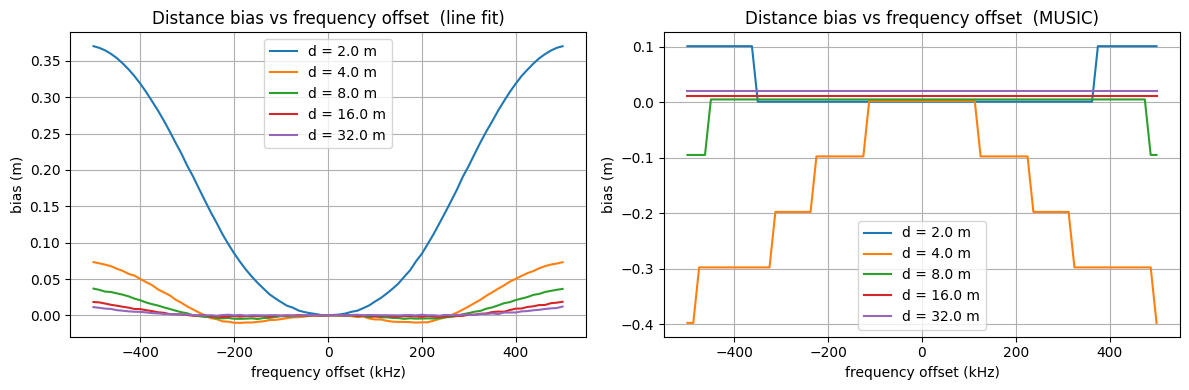

In [5]:
# Sweep the carrier-frequency offset over +/- half the tone spacing, once per method.
freq_offsets = np.linspace(-0.5 * delta_f, 0.5 * delta_f, 81)  # Hz
distances = [2.0, 4.0, 8.0, 16.0, 32.0]
methods = [('line_fit', 'line fit'), ('music', 'MUSIC')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (method, title_method) in zip(axes, methods):
    for d_true in distances:
        biases = np.zeros_like(freq_offsets)
        for i, foff in enumerate(freq_offsets):
            d_hat_i, *_ = simulate(d_true, freq_offset=foff, method=method)
            biases[i] = d_hat_i - d_true
        ax.plot(freq_offsets / 1e3, biases, label=f'd = {d_true} m')
    ax.set_title(f'Distance bias vs frequency offset  ({title_method})')
    ax.set_xlabel('frequency offset (kHz)')
    ax.set_ylabel('bias (m)')
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()


### Interactive sweep

Drag the sliders to see how the phase line and the recovered distance respond to **SNR** (0 – 30 dB) and **carrier-frequency offset** (0 – 120 kHz). Noise is reseeded to the same RNG state on every redraw, so changes you see are due to the sliders, not luck.


In [9]:
import io
from ipywidgets import (FloatSlider, IntSlider, ToggleButtons, Image,
                        HBox, VBox, Layout)
from IPython.display import display
from matplotlib.offsetbox import TextArea, HPacker, AnchoredOffsetbox

# Render figures into an Image widget rather than relying on matplotlib-inline +
# Output capture, which duplicates rows in this VS Code + ipywidgets env.

D_MIN_M, D_MAX_M = 1.0, 40.0
SNR_MIN_DB, SNR_MAX_DB = -6.0, 80.0
slider_layout = Layout(width='280px')
button_layout = Layout(width='auto', margin='0 14px')
button_style  = {'button_width': '100px', 'description_width': 'initial'}
button_row    = Layout(justify_content='center', width='100%')
LABEL_FS = 14

# Figure sized for a 16:9 monitor in full screen. Slider rows above the image
# eat ~200 px of vertical space, so the figure itself is widened to 16:7.5 so
# the rendered PNG (scaled to 100% container width) fits below the controls
# without forcing the user to scroll.
FIG_W_IN, FIG_H_IN = 16.0, 7.5
FIG_DPI = 110

d_true_m        = FloatSlider(min=D_MIN_M,    max=D_MAX_M,    step=1,    value=3,    description='d (m)',        layout=slider_layout)
snr_db          = FloatSlider(min=SNR_MIN_DB, max=SNR_MAX_DB, step=1,    value=20,   description='SNR (dB)',     layout=slider_layout)
freq_offset_khz = FloatSlider(min=0,          max=240,        step=10,   value=0,    description='Δf (kHz)',     layout=slider_layout)
n_tones         = IntSlider  (min=2,          max=80,         step=2,    value=80,   description='# tones',      layout=slider_layout)
delay_ns        = FloatSlider(min=0,          max=100,        step=1,    value=0,    description='delay (ns)',   layout=slider_layout)
delay_spread_ns = FloatSlider(min=0,          max=200,        step=1,    value=0,    description='τ_rms (ns)',   layout=slider_layout)
max_P           = IntSlider  (min=1,          max=20,         step=1,    value=6,    description='max peaks',    layout=slider_layout)
log10_thr       = FloatSlider(min=-2,         max=6,          step=0.1,  value=-1.0, description='log10_thr',    layout=slider_layout)
los_toggle      = ToggleButtons(options=[('LOS', True), ('NLOS', False)], value=True, description='channel', layout=button_layout, style=button_style)
method          = ToggleButtons(options=[('line fit', 'line_fit'), ('MUSIC', 'music')], value='music', description='estimator', layout=button_layout, style=button_style)
P_mode          = ToggleButtons(options=['auto', 'manual'], value='auto', description='MUSIC mode', layout=button_layout, style=button_style)
alg             = ToggleButtons(options=['1-way', '2-way'], value='1-way', description='Algorithm', layout=button_layout, style=button_style)


controls = [d_true_m, snr_db, freq_offset_khz, n_tones, delay_ns, delay_spread_ns,
            max_P, log10_thr, los_toggle, method, P_mode, alg]

out_img = Image(format='png', layout=Layout(width='100%'))


def _render(*_):
    rng = np.random.default_rng(0)

    # MUSIC needs P+1 <= L < N with L = N//2, so it requires N >= 4. Below
    # that, music_distance / auto_signal_dim raise -- fall back to line_fit
    # for the estimate and blank the bottom panels so the phase plot still
    # updates.
    L_max = n_tones.value // 2 - 1
    threshold = 10.0 ** log10_thr.value
    P_max = max(1, min(max_P.value, max(L_max, 1)))
    music_ok = n_tones.value >= 4

    if P_mode.value == 'auto':
        P_arg = 'auto'
    else:
        P_arg = P_max

    method_eff = method.value if music_ok else 'line_fit'

    d_hat, phases, phasors, m, b, H = simulate(
        d_true_m.value, snr_db=snr_db.value,
        freq_offset=freq_offset_khz.value * 1e3,
        n_tones=n_tones.value,
        delay=delay_ns.value * 1e-9,
        delay_spread=delay_spread_ns.value * 1e-9,
        los=los_toggle.value,
        rng=rng, method=method_eff,
        P=P_arg, P_max=P_max, alg=alg.value,
        music_threshold=threshold,
    )
    freqs_local = np.arange(n_tones.value) * delta_f

    if music_ok:
        d_music_arr, distances_music, P_music, eigvals = music_distance(
            phasors, delta_f, P=P_arg, P_max=P_max, alg=alg.value, threshold=threshold,
        )
        # Resolve the actual P used for the eigenvalue-coloring panel. In auto
        # mode, music_distance picked it from `eigvals` via auto_signal_dim;
        # recompute here with the same inputs to label the plot consistently.
        if P_arg == 'auto':
            P_paths = auto_signal_dim(eigvals, P_max=P_max, L_max=L_max)
        else:
            P_paths = P_arg

    # 2x2 layout:
    #   (0,0) phase vs freq         (0,1) channel impulse response
    #   (1,0) MUSIC eigenvalues     (1,1) MUSIC pseudo-spectrum
    fig, axes = plt.subplots(2, 2, figsize=(FIG_W_IN, FIG_H_IN))
    ax    = axes[0, 0]
    ax_ir = axes[0, 1]
    ax_ev = axes[1, 0]
    ax_mu = axes[1, 1]

    # (0,0) phase + fits. In 2-way the actual phase ramp is doubled
    # (TX is squared), so the true-slope reference line gets 2·d_true.
    round_trip = 2.0 if alg.value == '2-way' else 1.0
    ax.plot(freqs_local/1e6, phases, '.', color='C0', label='measured phases')
    ax.plot(freqs_local/1e6, m * freqs_local + b, '-', color='red', alpha=0.5,
            linewidth=1.2, label=r'estimated')
    true_slope = -2 * np.pi * round_trip * d_true_m.value / c
    ax.plot(freqs_local/1e6, true_slope * freqs_local + 0, '--', color='green',
            alpha=0.8, linewidth=1.2,
            label=fr'true')
    #ax.set_ylim(-60,10)
    ax.set_xlabel('tone frequency (MHz)', fontsize=LABEL_FS)
    ax.set_ylabel('unwrapped phase (rad)', fontsize=LABEL_FS)
    los_label = 'LOS' if los_toggle.value else 'NLOS'
    title_suffix = '' if music_ok else '  [line fit -- MUSIC needs N ≥ 4]'
    err = d_hat - d_true_m.value
    # Centered two-color title: black "true/est" + red "err" packed horizontally.
    main_txt = TextArea(f'true d={d_true_m.value:.3f} m,  est d={d_hat:.3f} m{title_suffix},  ',
                        textprops=dict(fontsize=LABEL_FS, color='black'))
    err_txt  = TextArea(f'err={err:+.3f} m',
                        textprops=dict(fontsize=LABEL_FS, color='red'))
    title_box = HPacker(children=[main_txt, err_txt], align='center', pad=0, sep=0)
    ax.add_artist(AnchoredOffsetbox(
        loc='lower center', child=title_box, pad=0, borderpad=0, frameon=False,
        bbox_to_anchor=(0.5, 1.02), bbox_transform=ax.transAxes,
    ))
    ax.tick_params(labelsize=LABEL_FS)
    ax.legend(loc='best', fontsize=LABEL_FS)
    ax.grid(True, alpha=0.3)

    # (0,1) channel impulse response
    h_t = np.fft.ifft(H)
    M_local = OSR * n_tones.value
    t_ir_ns = np.arange(M_local) / (OSR * n_tones.value * delta_f) * 1e9
    ax_ir.plot(t_ir_ns, np.abs(h_t), color='C1', label='Im')
    ax_ir.set_xlabel('time (ns)', fontsize=LABEL_FS)
    ax_ir.set_ylabel('h(t)', fontsize=LABEL_FS)
    ax_ir.set_title(f'Channel impulse response  [{los_label}]', fontsize=LABEL_FS)
    ax_ir.tick_params(labelsize=LABEL_FS)
    ax_ir.legend(fontsize=LABEL_FS)
    ax_ir.grid(True, alpha=0.3)
    ax_ir.set_xlim(0, 500)

    if music_ok:
        # (1,0) MUSIC eigenvalues (descending). Top P_paths = signal subspace,
        # remaining L - P_paths = noise subspace.
        idx = np.arange(eigvals.size)
        ax_ev.semilogy(idx[:P_paths], eigvals[:P_paths], 'o', color='C3',
                       markersize=5, label=f'signal')
        ax_ev.semilogy(idx[P_paths:], eigvals[P_paths:], 'o', color='C0',
                       markersize=5, label=f'noise')
        ax_ev.axvline(P_paths - 0.5, color='gray', linestyle=':', alpha=0.5)
        ax_ev.set_xlabel('eigenvalue index (descending)', fontsize=LABEL_FS)
        ax_ev.set_ylabel('eigenvalue (log scale)', fontsize=LABEL_FS)
        ax_ev.set_title('Sample-covariance eigenvalues', fontsize=LABEL_FS)
        ax_ev.set_ylim(1e-9, 1e3)
        ax_ev.tick_params(labelsize=LABEL_FS)
        ax_ev.legend(loc='best', fontsize=LABEL_FS)
        ax_ev.grid(True, which='both', alpha=0.3)

        # (1,1) MUSIC pseudo-spectrum (in 1-way distance for both algs;
        # music_distance already halves its grid in 2-way mode).
        ax_mu.semilogy(distances_music, P_music, color='C0', linewidth=1.2)
        ax_mu.axhline(threshold, color='black', linestyle='--', linewidth=2.0, alpha=1.0,
                      label=f'threshold = {threshold:.3g}', zorder=5)
        ax_mu.axvline(d_true_m.value, color='C2', linestyle='--', alpha=0.8,
                      label=f'true d = {d_true_m.value:.2f} m')
        ax_mu.axvline(d_music_arr[0], color='C3', linestyle='--', alpha=0.8,
                      label=f'MUSIC d̂ = {d_music_arr[0]:.3f} m')
        ax_mu.set_xlabel('distance (m)', fontsize=LABEL_FS)
        ax_mu.set_ylabel(r'$P_\mathrm{MUSIC}(d)$  (log scale)', fontsize=LABEL_FS)
        ax_mu.set_title('MUSIC pseudo-spectrum', fontsize=LABEL_FS)
        ax_mu.set_ylim(1e-2, 1e3)
        ax_mu.tick_params(labelsize=LABEL_FS)
        ax_mu.legend(loc='best', fontsize=LABEL_FS)
        ax_mu.grid(True, which='both', alpha=0.3)
        ax_mu.set_xlim(0, 150)
    else:
        msg = f'MUSIC unavailable\n(needs N ≥ 4, have N = {n_tones.value})'
        for ax_blank in (ax_ev, ax_mu):
            ax_blank.text(0.5, 0.5, msg, ha='center', va='center',
                          transform=ax_blank.transAxes, fontsize=LABEL_FS,
                          color='gray')
            ax_blank.set_xticks([])
            ax_blank.set_yticks([])

    fig.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=FIG_DPI, bbox_inches='tight')
    plt.close(fig)
    out_img.value = buf.getvalue()


for w in controls:
    w.observe(_render, names='value')
_render()

display(VBox([
    HBox(controls[0:4]),
    HBox(controls[4:8]),
    HBox(controls[8:12], layout=button_row),
    out_img,
]))